# ACDC SAX and M&Ms2 LAX Grad-CAM overlays

Inspect a trained **stacked ED/ES ResNet** checkpoint on central SAX slices, then export original images, Grad-CAM overlays, and segmentation overlays. This notebook uses the repository's patient splits and evaluation transforms.

Use Python 3.11 with CineMA and the project dependencies installed. Run cells in order from the project root or `notebooks/` directory. The default checkpoints are the relocated ACDC SAX and M&Ms2 LAX ResNet50 models, seed 0. The final sections also run the long-axis model and export its images.

## 1. Choose paths and patients

Dataset and checkpoint roots come from `configs/acdc_2d.yaml`. Set `ACDC_PROCESSED_DIR` or `ACDC_CHECKPOINT` to override them, including checkpoints from newer training runs. PNG exports go to `outputs/gradcam/` in this project.


In [6]:
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import SimpleITK as sitk
import torch
import torch.nn.functional as F
from omegaconf import DictConfig, OmegaConf

# Find the repository from its root or notebooks/ directory.
PROJECT_ROOT = next(
    (
        path
        for path in (Path.cwd(), *Path.cwd().parents)
        if (path / "main.py").is_file() and (path / "configs/acdc_2d.yaml").is_file()
    ),
    None,
)
if PROJECT_ROOT is None:
    raise RuntimeError(
        "Open this notebook from within the cardiac MRI classification checkout."
    )
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Reuse the paths configured for training; environment overrides remain available.
path_config = OmegaConf.load(PROJECT_ROOT / "configs/acdc_2d.yaml")
DATA_ROOT = (
    Path(os.environ.get("ACDC_PROCESSED_DIR", path_config.data.acdc_processed))
    .expanduser()
    .resolve()
)
CHECKPOINT_ROOT = Path(path_config.logging.dir).expanduser().resolve()
CHECKPOINT_PATH = (
    Path(
        os.environ.get(
            "ACDC_CHECKPOINT",
            str(
                CHECKPOINT_ROOT
                / "2d/acdc_sax_mid_2d/resnet50/stacked/imagenet/seed_0/best_val_mcc.pt"
            ),
        )
    )
    .expanduser()
    .resolve()
)
OUTPUT_ROOT = PROJECT_ROOT / "outputs" / "gradcam"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SPLIT = "train"
CLASS_NAME = "HCM"  # Set to None to include every class.
N_SAMPLES = 4

lax_path_config = OmegaConf.load(PROJECT_ROOT / "configs/architecture_bank.yaml")
LAX_DATA_ROOT = (
    Path(os.environ.get("MNMS2_PROCESSED_DIR", lax_path_config.data.mnms2_processed))
    .expanduser()
    .resolve()
)
LAX_CHECKPOINT_PATH = (
    Path(
        os.environ.get(
            "MNMS2_LAX_CHECKPOINT",
            str(
                Path(lax_path_config.logging.dir).expanduser()
                / "2d/mnms2_lax_4c/resnet50/stacked/imagenet/seed_0/best_val_mcc.pt"
            ),
        )
    )
    .expanduser()
    .resolve()
)
LAX_CLASS_NAME = "HCM"  # Set to None to include every M&Ms2 class.
LAX_N_SAMPLES = 4
LAX_OUTPUT_ROOT = OUTPUT_ROOT / "mnms2_lax_4c"

print("Repository:", PROJECT_ROOT)
print("Data root:", DATA_ROOT)
print("Checkpoint:", CHECKPOINT_PATH)
print("Output root:", OUTPUT_ROOT)
print("Device:", DEVICE)

Repository: /media/kislay/New Volume/Turab/0. Code workspace/0. cardiac mri classification
Data root: /media/kislay/New Volume/Turab/0. Code workspace/Data and models/datasets/acdc
Checkpoint: /media/kislay/New Volume/Turab/0. Code workspace/Data and models/model checkpoints/2d/acdc_sax_mid_2d/resnet50/stacked/imagenet/seed_0/best_val_mcc.pt
Output root: /media/kislay/New Volume/Turab/0. Code workspace/0. cardiac mri classification/outputs/gradcam
Device: cpu


## 2. Restore the model

Load the ACDC checkpoint and its companion `architecture.json`. The saved initialization controls input normalization; restored weights need no ImageNet download. The model remains in evaluation mode.


In [7]:
from cinema.classification.dataset import (
    EndDiastoleEndSystoleDataset,
    get_image_transforms,
)
from src.dataset import (
    ACDCMidSAX2DDataset,
    acdc_2d_load_official_splits,
    acdc_2d_split_directory,
    get_mid_sax_transforms,
    split_metadata,
)
from src.models import ArchitectureBank2DClassifier
from src.protocol import TASKS, protocols


def load_classifier(checkpoint_path: Path, data_root: Path, task_key: str):
    """Restore a stacked ResNet and the preprocessing saved alongside it."""
    architecture_path = checkpoint_path.parent / "architecture.json"
    for path in (checkpoint_path, architecture_path):
        if not path.is_file():
            raise FileNotFoundError(
                f"Missing {path}. Choose a trained 2-D checkpoint "
                "with its companion architecture.json."
            )
    checkpoint = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
    architecture = json.loads(architecture_path.read_text())
    if architecture["task"] != task_key or checkpoint["task"] != task_key:
        raise ValueError(f"Checkpoint does not match the requested task: {task_key}")
    backbone = checkpoint["backbone"]
    formulation = checkpoint["formulation"]
    initialization = checkpoint["initialization"]
    classes = tuple(checkpoint["classes"])
    expected_classes = (
        protocols["acdc"]["classes"]
        if task_key == protocols["acdc_2d"]["task_key"]
        else TASKS[task_key].classes
    )
    if classes != expected_classes:
        raise ValueError(f"Checkpoint class order does not match {task_key}: {classes}")
    if not backbone.startswith("resnet") or formulation != "stacked":
        raise ValueError("This notebook requires stacked ED/ES ResNet checkpoints.")

    # Restoring weights requires no ImageNet download. Keep saved normalization.
    model = ArchitectureBank2DClassifier(
        backbone, formulation, "randinit", len(classes)
    )
    model.load_state_dict(checkpoint["model"], strict=True)
    model.initialization = initialization
    model = model.to(DEVICE).eval()
    config = OmegaConf.create(architecture["config"])
    config.data.dir = str(data_root)
    print(
        f"Loaded {task_key}: {backbone} ({formulation}, {initialization}); classes={classes}"
    )
    return model, model.encoder.layer4[-1], config, classes


model, target_layer, inference_config, classes = load_classifier(
    CHECKPOINT_PATH, DATA_ROOT, protocols["acdc_2d"]["task_key"]
)

Loaded acdc_sax_mid_2d: resnet50 (stacked, imagenet); classes=('DCM', 'HCM', 'MINF', 'NOR', 'RV')


## 3. Load and inspect patients

Choose `train`, `val`, or `test`, a class, and the sample count in the first cell. Validation patients come from the training directory. Images use the checkpoint's evaluation transforms; ground-truth masks use the same slice and spatial padding.


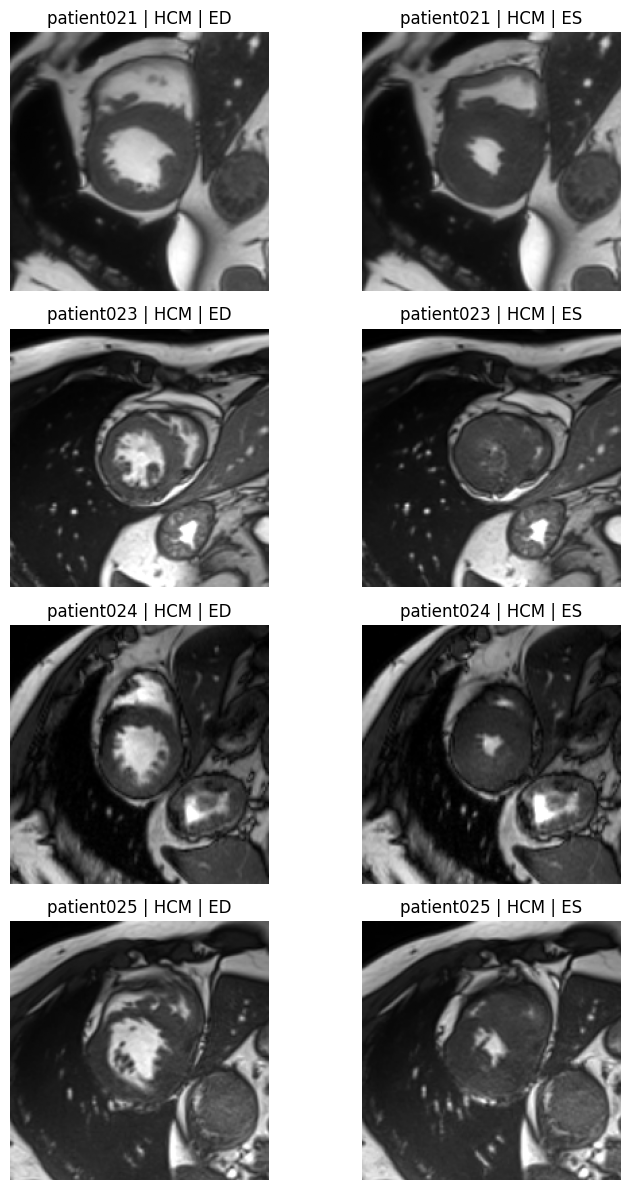

In [8]:
def load_samples(
    data_root: Path,
    config: DictConfig,
    task_key: str,
    split: str = "train",
    n_samples: int = 4,
    class_name: str | None = None,
) -> list[dict]:
    """Load official split patients with the checkpoint's evaluation transforms."""
    if split not in ("train", "val", "test"):
        raise ValueError(f"Unknown split: {split!r}")
    if type(n_samples) is not int or n_samples < 1:
        raise ValueError("n_samples must be a positive integer")
    if task_key == protocols["acdc_2d"]["task_key"]:
        classes = protocols["acdc"]["classes"]
        metadata = acdc_2d_load_official_splits(data_root)[split]
        view = "sax"
        data_dir = acdc_2d_split_directory(data_root, split)
        _, eval_transform = get_mid_sax_transforms(config)
    elif task_key == "mnms2_lax_4c":
        spec = TASKS[task_key]
        classes = spec.classes
        metadata = split_metadata(spec, data_root)[split]
        view = spec.view
        data_dir = data_root / split
        if config.model.views != view:
            raise ValueError(
                f"Expected checkpoint view {view}, got {config.model.views}"
            )
        _, eval_transform = get_image_transforms(config)
    else:
        raise ValueError(f"Unsupported notebook task: {task_key}")
    if class_name is not None:
        requested_class = class_name.strip().upper()
        if requested_class not in classes:
            raise ValueError(f"Unknown {task_key} class: {class_name!r}")
        metadata = metadata[metadata["pathology"] == requested_class]
    metadata = metadata.head(n_samples)
    if metadata.empty:
        raise ValueError(f"No patients found for {split}/{class_name}")

    if view == "sax":
        dataset = ACDCMidSAX2DDataset(data_dir, metadata, transform=None)
    else:
        dataset = EndDiastoleEndSystoleDataset(
            data_dir,
            metadata,
            class_col=config.data.class_column,
            classes=list(classes),
            views=view,
        )
    samples = []
    for index in range(len(dataset)):
        sample = dataset[index]
        slice_index = int(sample.get("slice_index", 0))
        masks = []
        for phase in ("ed", "es"):
            mask_path = (
                data_dir / sample["pid"] / f"{sample['pid']}_{view}_{phase}_gt.nii.gz"
            )
            if not mask_path.is_file():
                raise FileNotFoundError(mask_path)
            mask = np.transpose(sitk.GetArrayFromImage(sitk.ReadImage(str(mask_path))))
            if (
                mask.ndim != 3
                or mask.shape[:2] != tuple(sample[f"{view}_image"].shape[-2:])
                or slice_index >= mask.shape[-1]
            ):
                raise ValueError(f"Segmentation does not match the image: {mask_path}")
            masks.append(mask[..., slice_index].astype(np.uint8))

        image = eval_transform(sample)[f"{view}_image"].cpu().numpy()
        mask = np.stack(masks, axis=0)
        # Evaluation pads at the end of each spatial axis; pad masks identically.
        mask = np.pad(
            mask,
            (
                (0, 0),
                (0, image.shape[-2] - mask.shape[-2]),
                (0, image.shape[-1] - mask.shape[-1]),
            ),
        )
        samples.append(
            {
                "pid": sample["pid"],
                "class": sample["class"],
                "image": image,
                "mask": mask,
            }
        )
    return samples


samples = load_samples(
    DATA_ROOT,
    inference_config,
    protocols["acdc_2d"]["task_key"],
    SPLIT,
    N_SAMPLES,
    CLASS_NAME,
)
fig, axes = plt.subplots(len(samples), 2, figsize=(8, 3 * len(samples)), squeeze=False)
for row_index, sample in enumerate(samples):
    for phase_index, phase in enumerate(("ED", "ES")):
        ax = axes[row_index, phase_index]
        ax.imshow(sample["image"][phase_index], cmap="gray", vmin=0, vmax=1)
        ax.set_title(f"{sample['pid']} | {sample['class']} | {phase}")
        ax.axis("off")
fig.tight_layout()
plt.show()
plt.close(fig)

## 4. Grad-CAM and segmentation overlays

Grad-CAM targets the predicted class logit. A stacked model produces one **joint ED/ES heatmap**. It is shown over ED below and over both phases in the exports. Segmentation overlays show the dataset's ground-truth labels.


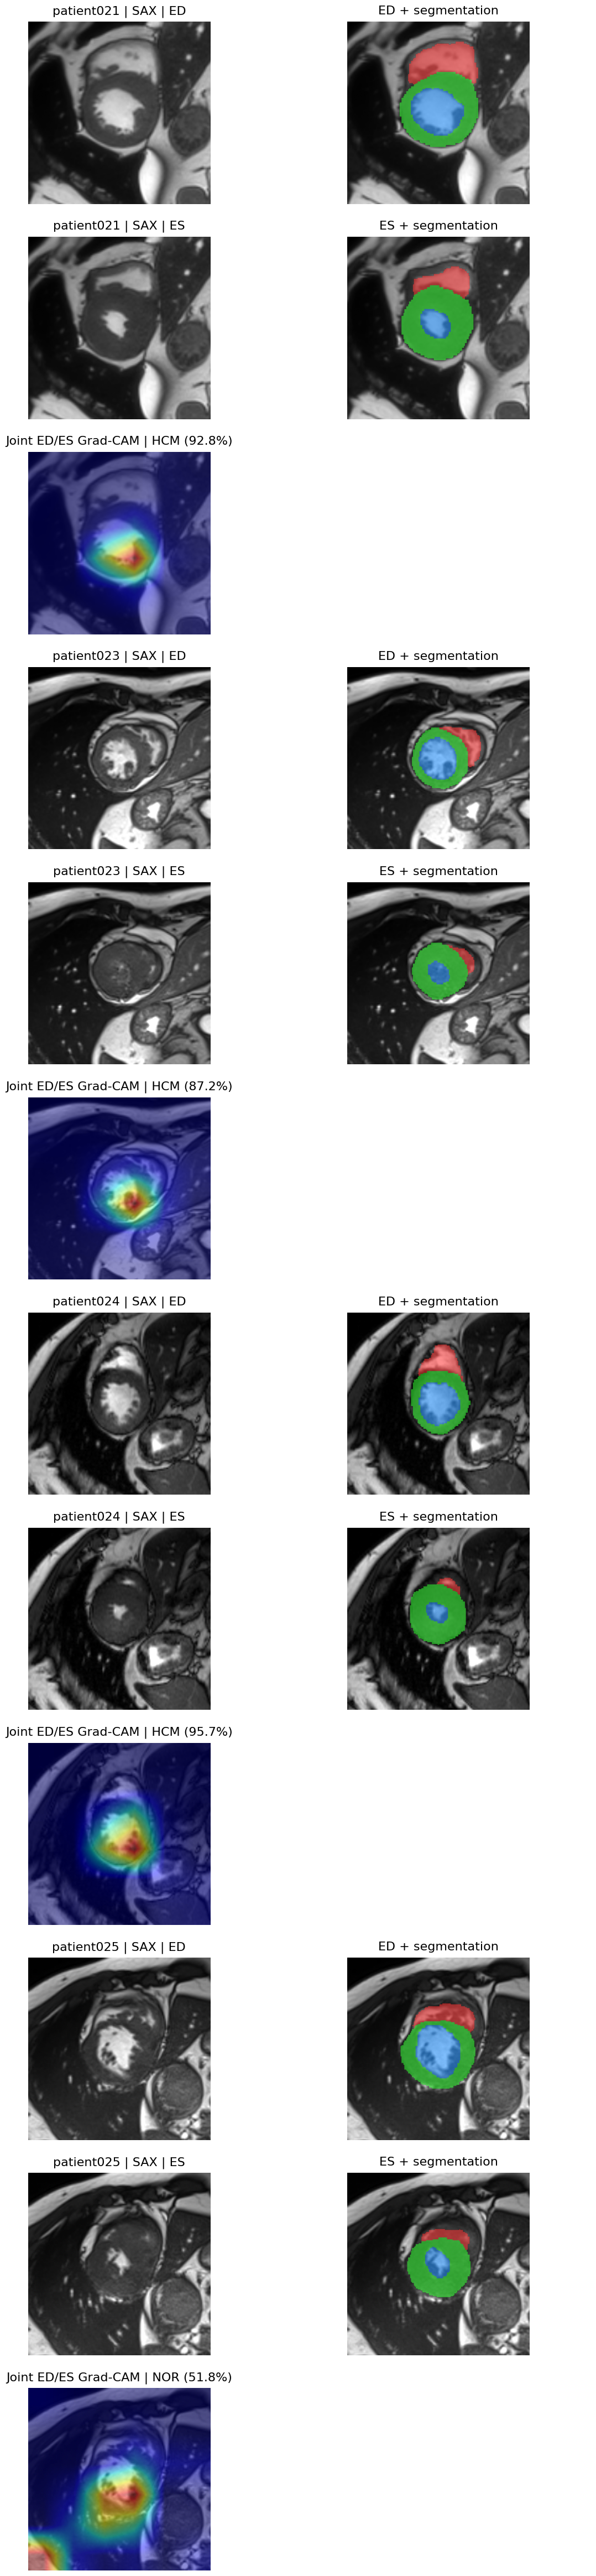

In [9]:
concept_cmap = ListedColormap(
    [[0, 0, 0, 0], [1, 0.2, 0.2, 0.55], [0.2, 1, 0.2, 0.55], [0.1, 0.55, 1, 0.55]]
)


def gradcam(
    sample: dict, model: torch.nn.Module, target_layer: torch.nn.Module
) -> tuple[np.ndarray, int, float]:
    """Explain the predicted logit with one joint heatmap for stacked ED/ES."""
    image = torch.as_tensor(
        sample["image"], dtype=torch.float32, device=next(model.parameters()).device
    )
    image = image.unsqueeze(0).requires_grad_(True)
    activations = []
    handle = target_layer.register_forward_hook(
        lambda _module, _inputs, output: activations.append(output)
    )
    try:
        with torch.enable_grad():
            logits = model(image)
            class_index = int(logits.argmax(dim=1).item())
            feature_map = activations[0]
            (gradient,) = torch.autograd.grad(logits[0, class_index], feature_map)
            weights = gradient.mean(dim=(2, 3), keepdim=True)
            heatmap = torch.relu((weights * feature_map).sum(dim=1, keepdim=True))
            heatmap = F.interpolate(
                heatmap, size=image.shape[-2:], mode="bilinear", align_corners=False
            )[0, 0]
            heatmap = heatmap / heatmap.max().clamp_min(1e-8)
            probability = logits.softmax(dim=1)[0, class_index].item()
            return heatmap.detach().cpu().numpy(), class_index, probability
    finally:
        handle.remove()


def plot_gradcam(
    samples: list[dict], cam_results: list, classes: tuple[str, ...], view_label: str
):
    """Show original images, segmentations, and joint ED/ES Grad-CAM results."""
    fig, axes = plt.subplots(
        len(samples) * 3, 2, figsize=(12, 12 * len(samples)), squeeze=False
    )
    for patient_index, (sample, (heatmap, class_index, probability)) in enumerate(
        zip(samples, cam_results, strict=True)
    ):
        row = patient_index * 3
        for phase_index, phase in enumerate(("ED", "ES")):
            image = sample["image"][phase_index]
            for column in range(2):
                axes[row + phase_index, column].imshow(
                    image, cmap="gray", vmin=0, vmax=1
                )
            axes[row + phase_index, 0].set_title(
                f"{sample['pid']} | {view_label} | {phase}", fontsize=16, pad=10
            )
            axes[row + phase_index, 1].imshow(
                sample["mask"][phase_index], cmap=concept_cmap, vmin=0, vmax=3
            )
            axes[row + phase_index, 1].set_title(
                f"{phase} + segmentation", fontsize=16, pad=10
            )
        axes[row + 2, 0].imshow(sample["image"][0], cmap="gray", vmin=0, vmax=1)
        axes[row + 2, 0].imshow(heatmap, cmap="jet", alpha=0.45, vmin=0, vmax=1)
        axes[row + 2, 0].set_title(
            f"Joint ED/ES Grad-CAM | {classes[class_index]} ({probability:.1%})",
            fontsize=16,
            pad=10,
        )
    for ax in axes.flat:
        ax.axis("off")
    fig.subplots_adjust(
        left=0.03, right=0.97, top=0.98, bottom=0.02, wspace=0.05, hspace=0.18
    )
    plt.show()
    plt.close(fig)


# Reuse these heatmaps when exporting instead of running the model again.
cam_results = [gradcam(sample, model, target_layer) for sample in samples]
plot_gradcam(samples, cam_results, classes, "SAX")

## 5. Export PNGs

Each patient and phase has the same filename across the original, Grad-CAM, and segmentation directories. The selected class determines the folder names.


In [12]:
def save_image(
    image: np.ndarray,
    path: Path,
    overlay: np.ndarray | None = None,
    **overlay_kwargs,
) -> None:
    """Save one image, optionally with a heatmap or segmentation overlay."""
    fig, ax = plt.subplots(figsize=(6, 6))
    try:
        ax.imshow(image, cmap="gray", vmin=0, vmax=1)
        if overlay is not None:
            ax.imshow(overlay, **overlay_kwargs)
        ax.axis("off")
        fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
        fig.savefig(path, dpi=300, bbox_inches="tight", pad_inches=0)
    finally:
        plt.close(fig)


def export_samples(
    samples: list[dict], cam_results: list, output_root: Path, class_name: str | None
):
    """Save matching ED/ES PNGs in the original, Grad-CAM, and segmentation folders."""
    class_label = class_name.strip().upper() if class_name is not None else "all"
    directories = {
        "original": output_root / f"01_{class_label}_original",
        "gradcam": output_root / f"02_{class_label}_gradcam",
        "segmentation": output_root / f"03_{class_label}_segmentation",
    }
    for directory in directories.values():
        directory.mkdir(parents=True, exist_ok=True)
    for sample, (heatmap, _, _) in zip(samples, cam_results, strict=True):
        for phase_index, phase in enumerate(("ED", "ES")):
            image = sample["image"][phase_index]
            filename = f"{sample['pid']}_{phase}.png"
            save_image(image, directories["original"] / filename)
            save_image(
                image,
                directories["gradcam"] / filename,
                heatmap,
                cmap="jet",
                alpha=0.45,
                vmin=0,
                vmax=1,
            )
            save_image(
                image,
                directories["segmentation"] / filename,
                sample["mask"][phase_index],
                cmap=concept_cmap,
                vmin=0,
                vmax=3,
            )
    for name, directory in directories.items():
        print(f"{name.capitalize()} images: {directory}")
    return directories


directories = export_samples(samples, cam_results, OUTPUT_ROOT, CLASS_NAME)

Original images: /media/kislay/New Volume/Turab/0. Code workspace/0. cardiac mri classification/outputs/gradcam/01_HCM_original
Gradcam images: /media/kislay/New Volume/Turab/0. Code workspace/0. cardiac mri classification/outputs/gradcam/02_HCM_gradcam
Segmentation images: /media/kislay/New Volume/Turab/0. Code workspace/0. cardiac mri classification/outputs/gradcam/03_HCM_segmentation


## 6. M&Ms2 four-chamber long-axis images

Load the relocated `mnms2_lax_4c` checkpoint and select patients from the same `SPLIT`. Set `LAX_CLASS_NAME`, `LAX_N_SAMPLES`, and `LAX_CHECKPOINT_PATH` in the first cell. `MNMS2_PROCESSED_DIR` and `MNMS2_LAX_CHECKPOINT` provide environment overrides.

Long-axis ED/ES images use CineMA's LAX evaluation transforms, including the checkpoint's padding and intensity settings. The checkpoint has six classes: ARR, CIA, FALL, HCM, LV, and NOR.


M&Ms2 data root: /media/kislay/New Volume/Turab/0. Code workspace/Data and models/datasets/mnms2
LAX checkpoint: /media/kislay/New Volume/Turab/0. Code workspace/Data and models/model checkpoints/2d/mnms2_lax_4c/resnet50/stacked/imagenet/seed_0/best_val_mcc.pt
Loaded mnms2_lax_4c: resnet50 (stacked, imagenet); classes=('ARR', 'CIA', 'FALL', 'HCM', 'LV', 'NOR')


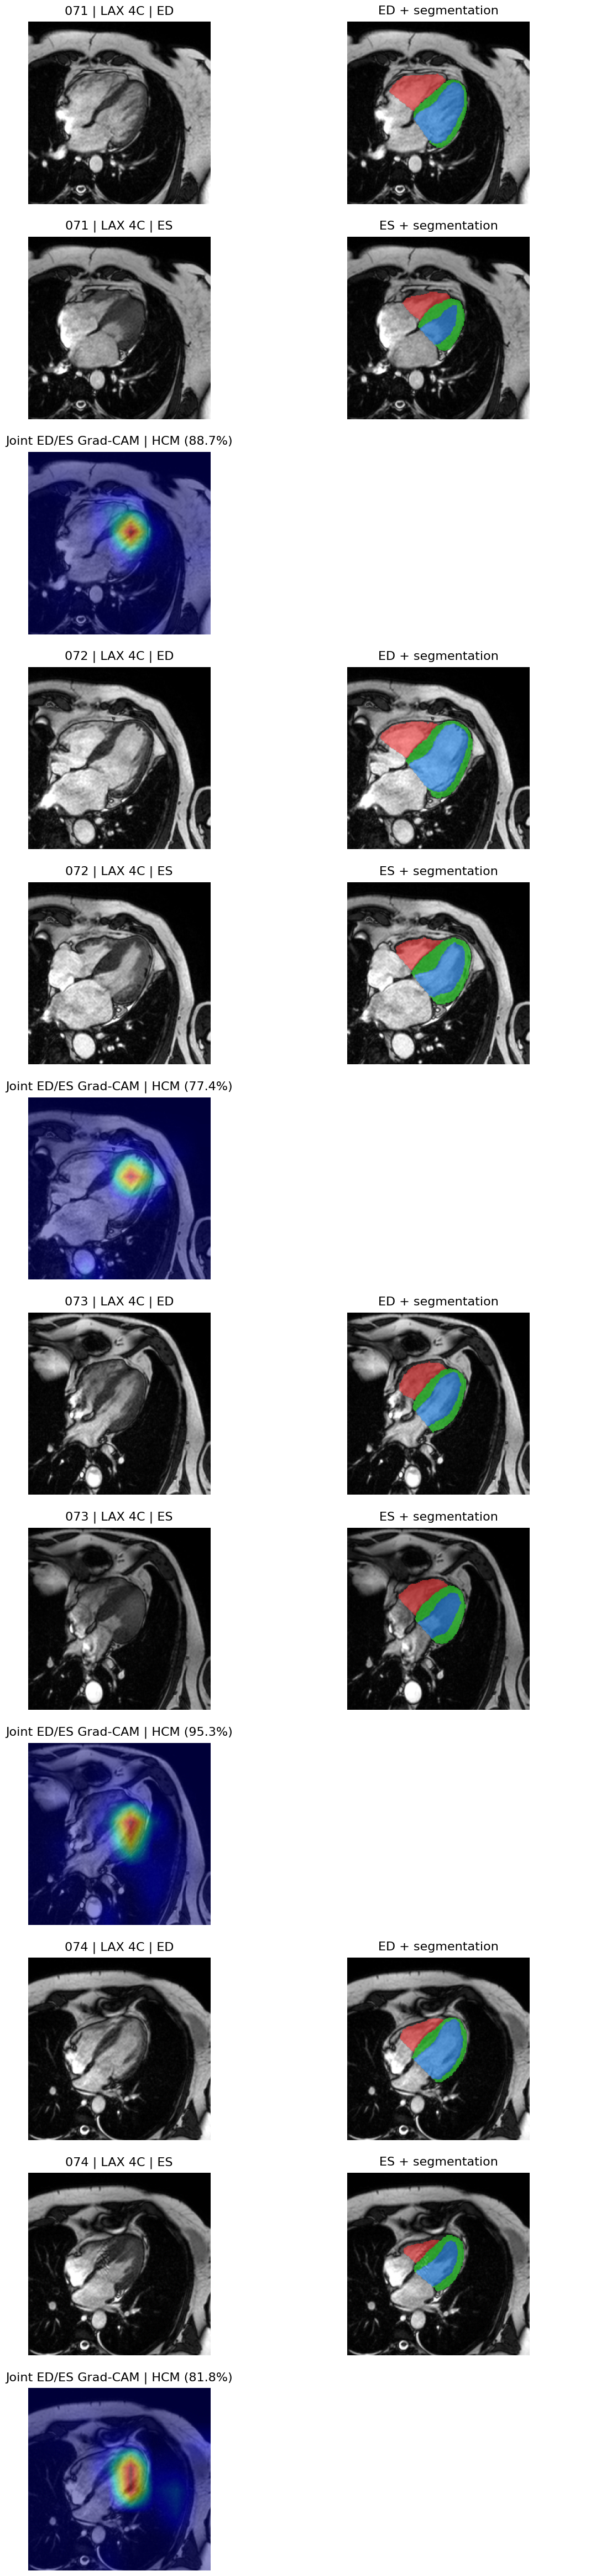

071: target=HCM, prediction=HCM (88.7%)
072: target=HCM, prediction=HCM (77.4%)
073: target=HCM, prediction=HCM (95.3%)
074: target=HCM, prediction=HCM (81.8%)


In [10]:
print("M&Ms2 data root:", LAX_DATA_ROOT)
print("LAX checkpoint:", LAX_CHECKPOINT_PATH)
lax_model, lax_target_layer, lax_config, lax_classes = load_classifier(
    LAX_CHECKPOINT_PATH, LAX_DATA_ROOT, "mnms2_lax_4c"
)
lax_samples = load_samples(
    LAX_DATA_ROOT,
    lax_config,
    "mnms2_lax_4c",
    SPLIT,
    LAX_N_SAMPLES,
    LAX_CLASS_NAME,
)
lax_cam_results = [
    gradcam(sample, lax_model, lax_target_layer) for sample in lax_samples
]
plot_gradcam(lax_samples, lax_cam_results, lax_classes, "LAX 4C")
for sample, (_, class_index, probability) in zip(
    lax_samples, lax_cam_results, strict=True
):
    print(
        f"{sample['pid']}: target={sample['class']}, "
        f"prediction={lax_classes[class_index]} ({probability:.1%})"
    )

## 7. Export long-axis PNGs

Save original ED/ES images, joint Grad-CAM overlays, and ground-truth segmentation overlays under `outputs/gradcam/mnms2_lax_4c/`. This keeps long-axis results separate from the ACDC SAX exports.


In [13]:
lax_directories = export_samples(
    lax_samples, lax_cam_results, LAX_OUTPUT_ROOT, LAX_CLASS_NAME
)

Original images: /media/kislay/New Volume/Turab/0. Code workspace/0. cardiac mri classification/outputs/gradcam/mnms2_lax_4c/01_HCM_original
Gradcam images: /media/kislay/New Volume/Turab/0. Code workspace/0. cardiac mri classification/outputs/gradcam/mnms2_lax_4c/02_HCM_gradcam
Segmentation images: /media/kislay/New Volume/Turab/0. Code workspace/0. cardiac mri classification/outputs/gradcam/mnms2_lax_4c/03_HCM_segmentation
